# Bati Bank — Feature Engineering

**Goal:** Transform raw transaction data into customer-level features for credit risk scoring.

**Flow:**
1. Load cleaned data from `data/processed/cleaned_data.csv`
2. Compute RFM features — one row per customer
3. Generate proxy labels using KMeans clustering
4. Build additional features for the model
5. Save feature table to `data/processed/features.csv`

> We start from cleaned data — no need to rerun loader or cleaner.

## 1. Setup and Imports

In [1]:
# Cell 1 — imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the parent directory (project root) to Python path
os.chdir('..')

from src.features.rfm import compute_rfm
from src.features.labels import generate_proxy_labels
from src.features.engineer import build_features
from src.model.train import (
    apply_adasyn, train_baseline,
    train_xgboost, get_metrics,
    save_model, save_feature_names
)
from src.model.evaluate import (
    plot_roc_curve, plot_confusion_matrix,
    plot_feature_importance, plot_model_comparison
)


print('Imports successful')

Imports successful


## 2. Load Cleaned Data

In [2]:
# Cell 2 — load from processed folder
# we saved this at the end of 01_eda.ipynb
df_clean = pd.read_csv(
    'data/processed/cleaned_data.csv',
    parse_dates=['TransactionStartTime']
)
print(f'Shape: {df_clean.shape}')
print(f'TransactionStartTime dtype: {df_clean["TransactionStartTime"].dtype}')
df_clean.head()

Shape: (95662, 16)
TransactionStartTime dtype: datetime64[ns, UTC]


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,is_reversal
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,1
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,1


In [3]:
# Cell 3 — quick check before we start
print(f'Date range   : {df_clean["TransactionStartTime"].min()} '
      f'to {df_clean["TransactionStartTime"].max()}')
print(f'Unique customers : {df_clean["CustomerId"].nunique()}')
print(f'Total transactions: {len(df_clean)}')

Date range   : 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00
Unique customers : 3742
Total transactions: 95662


### Observations
- Loaded from processed folder — no need to rerun cleaning pipeline
- 95,662 transactions → will collapse to 3,742 customer rows after RFM
- Date range: Nov 2018 → Feb 2019 (3 months)

## 3. RFM Features

In [4]:
# Cell 4 — compute RFM
# collapses 95,662 transaction rows → 3,742 customer rows
rfm = compute_rfm(df_clean)
print(f'RFM shape: {rfm.shape}')
rfm.head(10)

RFM shape: (3742, 4)


,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,83.72,1,-10000.0
1,CustomerId_10,83.72,1,-10000.0
2,CustomerId_1001,89.07,5,20000.0
3,CustomerId_1002,26.00,11,4225.0
4,CustomerId_1003,11.79,6,20000.0
5,CustomerId_1004,52.66,1,2000.0
6,CustomerId_1005,46.87,9,48800.0
7,CustomerId_1006,64.11,1,1000.0
8,CustomerId_1007,81.14,1,28000.0
9,CustomerId_1008,65.87,2,20000.0


In [5]:
# Cell 5 — understand the RFM distribution
rfm.describe()

,Recency,Frequency,Monetary
count,3742.000000,3742.000000,3.742000e+03
mean,31.006304,25.564404,1.717377e+05
std,27.131151,96.929602,2.717305e+06
min,0.000000,1.000000,-1.049000e+08
25%,5.100000,2.000000,4.077438e+03
50%,24.615000,7.000000,2.000000e+04
75%,53.600000,20.000000,7.996775e+04
max,90.270000,4091.000000,8.345124e+07


In [6]:
# Cell 6 — customers with only 1 transaction
# these are unknown risk — we cannot build a pattern from 1 data point
low_freq = rfm[rfm['Frequency'] == 1]
print(f'Customers with only 1 transaction : {len(low_freq)}')
print(f'That is {len(low_freq)/len(rfm)*100:.1f}% of all customers')

Customers with only 1 transaction : 712
That is 19.0% of all customers


In [7]:
# Cell 7 — customers with negative total monetary
# these customers paid more in fees/reversals than actual purchases
negative_monetary = rfm[rfm['Monetary'] < 0]
print(f'Customers with negative total amount : {len(negative_monetary)}')
print(f'That is {len(negative_monetary)/len(rfm)*100:.1f}% of customers')

Customers with negative total amount : 192
That is 5.1% of customers


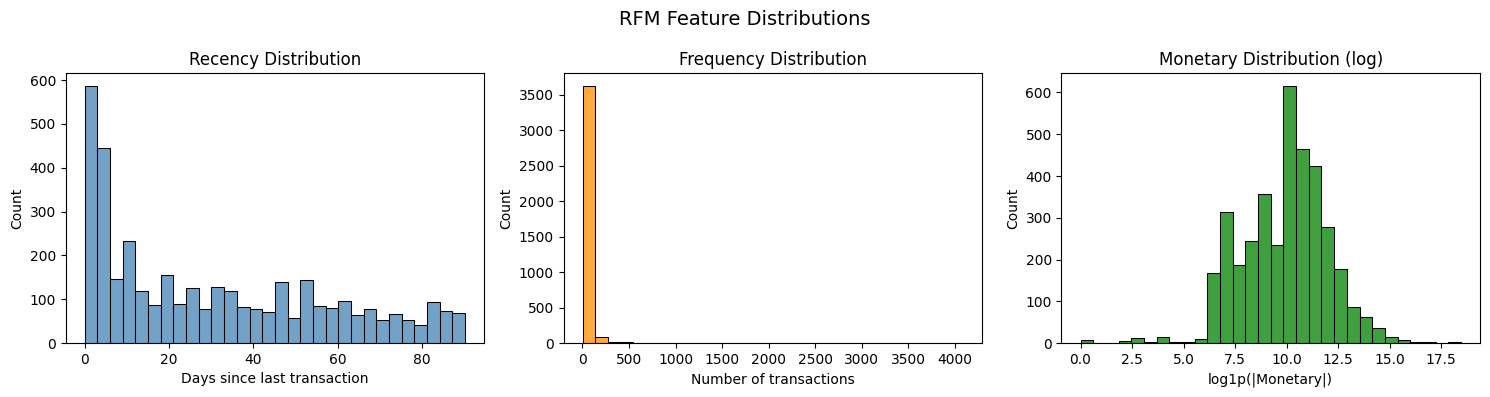

In [8]:
# Cell 8 — visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last transaction')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of transactions')

sns.histplot(np.log1p(np.abs(rfm['Monetary'])), bins=30, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution (log)')
axes[2].set_xlabel('log1p(|Monetary|)')

plt.suptitle('RFM Feature Distributions', fontsize=14)
plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/rfm_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### RFM Observations
2. Recency range  : min=0.0   max=90.27
3. Frequency range: min=1     max=4,091
4. Monetary range : min=-104,900,000  max=83,451,240
5. Recency distribution: right skewed — most customers 
   transacted recently, few were dormant for 90 days


## 4. Proxy Labels with KMeans

**Why KMeans?**

We have no ground truth labels for credit risk — FraudResult exists but only 193 cases.
Instead we cluster customers by RFM behavior. The cluster with:
- High recency (inactive)
- Low frequency (few transactions)
- Low monetary (low spend)

...becomes our **high risk proxy label (1)**. All others become **low risk (0)**.

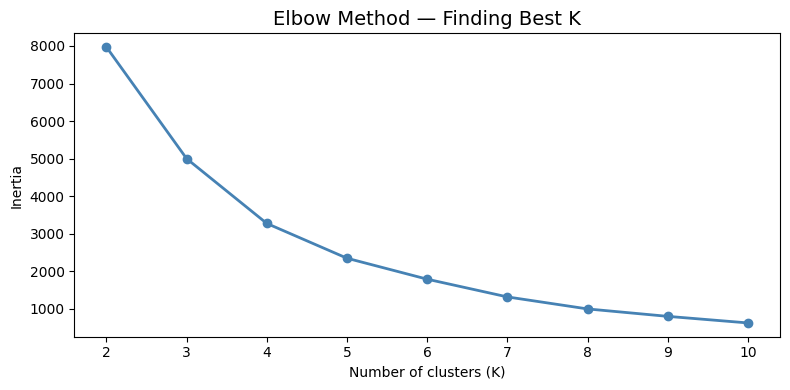


Cluster Summary (mean RFM per cluster):
         Recency  Frequency      Monetary
Cluster                                  
0          61.20       7.67  8.207588e+04
1          28.86    4091.00 -1.049000e+08
2          12.13      34.98  2.734298e+05

High risk cluster identified: Cluster 0

High risk customers : 1439
Low risk customers  : 2303
High risk rate      : 38.5%


In [9]:
# Cell 9 — run full pipeline
# this plots elbow, fits kmeans, assigns labels automatically
rfm_labeled, kmeans, scaler = generate_proxy_labels(rfm, n_clusters=3)


In [10]:
# Cell 10 — inspect result
print(rfm_labeled[['CustomerId', 'Recency', 'Frequency', 
                    'Monetary', 'Cluster', 'is_high_risk']].head(10))

        CustomerId  Recency  Frequency  Monetary  Cluster  is_high_risk
0     CustomerId_1    83.72          1  -10000.0        0             1
1    CustomerId_10    83.72          1  -10000.0        0             1
2  CustomerId_1001    89.07          5   20000.0        0             1
3  CustomerId_1002    26.00         11    4225.0        2             0
4  CustomerId_1003    11.79          6   20000.0        2             0
5  CustomerId_1004    52.66          1    2000.0        0             1
6  CustomerId_1005    46.87          9   48800.0        0             1
7  CustomerId_1006    64.11          1    1000.0        0             1
8  CustomerId_1007    81.14          1   28000.0        0             1
9  CustomerId_1008    65.87          2   20000.0        0             1


In [11]:
rfm_labeled.to_csv('data/processed/rfm_features.csv', index=False)
print(f'Saved: data/processed/rfm_features.csv')
print(f'Shape: {rfm_labeled.shape}')
print(f'Columns: {rfm_labeled.columns.tolist()}')

Saved: data/processed/rfm_features.csv
Shape: (3742, 6)
Columns: ['CustomerId', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'is_high_risk']


### Elbow observation
- The elbow appears at K = 3
- Decision: use K = 3

### KMeans Results

| Cluster | Recency | Frequency | Monetary | Label |
|---|---|---|---|---|
| 0 | 61.20 | 7.67 | 82,075 | HIGH RISK |
| 1 | 28.86 | 4,091 | -104,900,000 | outlier cluster |
| 2 | 12.13 | 34.98 | 273,429 | low risk |

**Key findings:**
- Cluster 0 = high risk: inactive (61 days), low frequency, low spend
- Cluster 1 = outlier: one customer with 4,091 transactions dominates
- Cluster 2 = best customers: recent, frequent, high spend
- High risk customers: 1,439 (38.5%)
- Low risk customers: 2,303 (61.5%)

**Note on Cluster 1:** extreme outlier pulled its own cluster.
Consider removing outlier customers before clustering in production.

In [12]:
# build all features
features = build_features(df_clean, rfm_labeled)
print(f"Features shape: {features.shape}")
print(f"Columns: {features.columns.tolist()}")
features.head()

Features shape: (3742, 23)
Columns: ['CustomerId', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'is_high_risk', 'avg_hour', 'avg_day_of_week', 'weekend_rate', 'transaction_month', 'std_amount', 'max_amount', 'min_amount', 'log_monetary', 'reversal_rate', 'unique_products', 'unique_providers', 'avg_daily_transactions', 'monetary_per_transaction', 'negative_amount_count', 'positive_amount_sum', 'velocity_last_30_days', 'recency_frequency_ratio']


,CustomerId,Recency,Frequency,Monetary,Cluster,is_high_risk,avg_hour,avg_day_of_week,weekend_rate,transaction_month,...,log_monetary,reversal_rate,unique_products,unique_providers,avg_daily_transactions,monetary_per_transaction,negative_amount_count,positive_amount_sum,velocity_last_30_days,recency_frequency_ratio
0,CustomerId_1,83.72,1,-10000.0,0,1,16.00,2.00,0.0000,11,...,9.210440,100.00,1,1,1.00,-10000.00,1.0,0.0,0.0,83.7200
1,CustomerId_10,83.72,1,-10000.0,0,1,16.00,2.00,0.0000,11,...,9.210440,100.00,1,1,1.00,-10000.00,1.0,0.0,0.0,83.7200
2,CustomerId_1001,89.07,5,20000.0,0,1,7.80,4.00,0.0000,11,...,9.903538,40.00,2,3,5.00,4000.00,2.0,25200.0,0.0,17.8140
3,CustomerId_1002,26.00,11,4225.0,2,0,13.45,2.91,0.1818,1,...,8.349011,54.55,2,2,1.83,384.09,6.0,4500.0,3.0,2.3636
4,CustomerId_1003,11.79,6,20000.0,2,0,14.33,4.00,0.0000,2,...,9.903538,33.33,2,3,6.00,3333.33,2.0,26000.0,6.0,1.9650


In [13]:
# check for any missing values in features
missing = features.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else "No missing values")

No missing values


In [14]:
# save
features.to_csv('data/processed/features.csv', index=False)
print(f"Saved: data/processed/features.csv")
print(f"Shape: {features.shape}")

Saved: data/processed/features.csv
Shape: (3742, 23)


## Feature Engineering Summary

| Group | Features | Count |
|---|---|---|
| RFM | Recency, Frequency, Monetary | 3 |
| Time | avg_hour, avg_day_of_week, weekend_rate, transaction_month | 4 |
| Amount | std_amount, max_amount, min_amount, log_monetary | 4 |
| Behavioral | reversal_rate, unique_products, unique_providers, avg_daily_transactions | 4 |
| Risk ratios | monetary_per_transaction, negative_amount_count, positive_amount_sum, velocity_last_30_days, recency_frequency_ratio | 5 |

**Final feature table:** 3,742 customers × 23 columns
**Target variable:** is_high_risk (1=high risk, 0=low risk)
**Missing values:** none
**Next step:** 03_train.ipynb — temporal split + XGBoost training

### Why Recall matters most for Bati Bank
- Recall = 0.9653 means 278/288 high risk customers caught
- 10 high risk customers missed = approved for BNPL credit
- Each missed customer risks defaulting on their loan
- Financial loss > missed sale
- Therefore we optimize for Recall over Precision

## Training Summary

| Step | Decision | Reason |
|---|---|---|
| Split type | Stratified (80/20) | Temporal split caused empty test set |
| Dropped columns | CustomerId, Cluster, is_high_risk, Recency | Leakage |
| Imbalance handling | ADASYN on train only | Real distribution in test |
| Baseline | Logistic Regression | Simple benchmark |
| Main model | XGBoost | Non-linear, robust to outliers |
| Tracking | MLflow | Reproducible experiments |

**Best model: XGBoost**
- AUC       : 0.9984
- F1        : 0.9754
- Precision : 0.9858
- Recall    : 0.9653

**Important note on performance:**
High AUC reflects cluster separability from KMeans proxy labels.
In production, real default labels would replace proxy labels.
Architecture is production-ready.

**Next step:** 04_explainability.ipynb — SHAP values